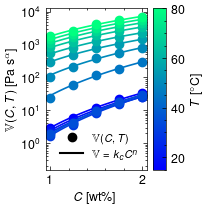

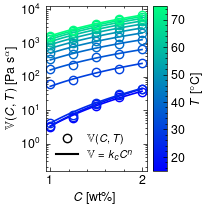

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
import scienceplots
import os

plt.style.use(['science', 'nature', 'bright'])

# Define a power law function
def power_law(x, a, b):
    return a * np.power(x, b)

# ------------------ Concentrations ------------------
# Folder names (as in ../results)
folder_names = ["1.00", "1.25", "1.50", "1.75", "2.00"]
# File names for CSVs (underscores)
file_names   = ["1_00", "1_25", "1_50", "1_75", "2_00"]

# ------------------ Paths ------------------
results_dir = "../results"
figures_dir = "../figures/main/power_law"
os.makedirs(figures_dir, exist_ok=True)

files_heating = [os.path.join(results_dir, folder, f"fitted_parameters_heating_conc_{fname}.csv")
                 for folder, fname in zip(folder_names, file_names)]
files_cooling = [os.path.join(results_dir, folder, f"fitted_parameters_cooling_conc_{fname}.csv")
                 for folder, fname in zip(folder_names, file_names)]

# ------------------ Load Data ------------------
data_heating_list = []
data_cooling_list = []

for f in files_heating:
    if os.path.exists(f):
        data_heating_list.append(pd.read_csv(f))
    else:
        print(f"Warning: file not found: {f}")

for f in files_cooling:
    if os.path.exists(f):
        data_cooling_list.append(pd.read_csv(f))
    else:
        print(f"Warning: file not found: {f}")

if not data_heating_list or not data_cooling_list:
    raise FileNotFoundError("Some expected CSV files are missing. Check the paths.")

data_heating = pd.concat(data_heating_list, ignore_index=True)
data_cooling = pd.concat(data_cooling_list, ignore_index=True)

unique_temperatures_heating = np.sort(data_heating['Temperature'].unique())
unique_temperatures_cooling = np.sort(data_cooling['Temperature'].unique())

# ------------------ Heating Plot ------------------
plt.figure(figsize=(2.13, 2.2))
ax = plt.gca()

norm_h = plt.Normalize(vmin=unique_temperatures_heating.min(), vmax=unique_temperatures_heating.max())
cmap = plt.cm.winter

for temp in unique_temperatures_heating:
    subset = data_heating[data_heating['Temperature'] == temp].dropna(subset=['Concentration', 'V'])
    if subset.empty:
        continue
    c_vals = subset['Concentration'].to_numpy()
    V_vals = subset['V'].to_numpy()
    color = cmap(norm_h(temp))

    ax.plot(c_vals, V_vals, linestyle='none', marker='o', markersize=6, color=color)

    try:
        popt, _ = curve_fit(power_law, c_vals, V_vals)
        c_fit = np.linspace(c_vals.min(), c_vals.max(), 100)
        V_fit = power_law(c_fit, *popt)
        ax.plot(c_fit, V_fit, color=color, lw=1.2)
    except Exception:
        pass

legend_elements = [
    Line2D([0], [0], marker='o', color='k', markerfacecolor='k', linestyle='none', markersize=6, label='$\mathbb{V}(C, T)$'),
    Line2D([0], [0], color='k', linewidth=1.5, label=r'$\mathbb{V} = k_{c} C^{n}$')
]
ax.legend(handles=legend_elements, fontsize=8, frameon=False, loc='best')
ax.set_yscale("log")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_h)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, aspect=12)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T~\\rm{[^{\\circ}C]}$', size=9)

ax.tick_params(axis='both', which='both', direction='in', labelsize=9)
ax.set_xlabel('$C~\mathrm{[wt\%]}$', fontsize=9)
ax.set_ylabel(r'$\mathbb{V}(C, T)~[\mathrm{Pa~s}^\alpha]$', fontsize=9)
ax.set_ylim(10**-0.8, 10**4.1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "power_law_fit_v_combined_heating.pdf"), dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ------------------ Cooling Plot ------------------
plt.figure(figsize=(2.13, 2.2))
ax = plt.gca()

norm_c = plt.Normalize(vmin=unique_temperatures_cooling.min(), vmax=unique_temperatures_cooling.max())

for temp in unique_temperatures_cooling:
    subset = data_cooling[data_cooling['Temperature'] == temp].dropna(subset=['Concentration', 'V'])
    if subset.empty:
        continue
    c_vals = subset['Concentration'].to_numpy()
    V_vals = subset['V'].to_numpy()
    color = cmap(norm_c(temp))

    ax.plot(c_vals, V_vals, linestyle='none', marker='o', markersize=6, color=color, mfc='none', mec=color)

    try:
        popt, _ = curve_fit(power_law, c_vals, V_vals)
        c_fit = np.linspace(c_vals.min(), c_vals.max(), 100)
        V_fit = power_law(c_fit, *popt)
        ax.plot(c_fit, V_fit, color=color, lw=1.2)
    except Exception:
        pass

legend_elements = [
    Line2D([0], [0], marker='o', color='k', markerfacecolor='none', markeredgecolor='k',
           linestyle='none', markersize=6, label='$\mathbb{V}(C, T)$'),
    Line2D([0], [0], color='k', linewidth=1.5, label=r'$\mathbb{V} = k_{c} C^{n}$')
]
ax.legend(handles=legend_elements, fontsize=8, frameon=False, loc='best')
ax.set_yscale("log")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, aspect=12)
cbar.ax.tick_params(labelsize=9)
cbar.set_label('$T~\\rm{[^{\\circ}C]}$', size=9)

ax.tick_params(axis='both', which='both', direction='in', labelsize=9)
ax.set_xlabel('$C~\mathrm{[wt\%]}$', fontsize=9)
ax.set_ylabel(r'$\mathbb{V}(C, T)~[\mathrm{Pa~s}^\alpha]$', fontsize=9)
ax.set_ylim(10**-0.8, 10**4.1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "power_law_fit_v_combined_cooling.pdf"), dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


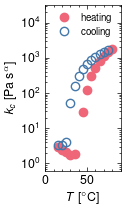

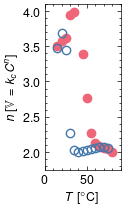

In [6]:
# ---- Fit per-temperature power-law for heating ----
power_law_params_heating = []
for temp in unique_temperatures_heating:
    subset = data_heating[data_heating['Temperature'] == temp].dropna(subset=['Concentration', 'V'])
    if subset.empty:
        continue
    c_vals = subset['Concentration'].to_numpy(dtype=float)
    V_vals = subset['V'].to_numpy(dtype=float)
    try:
        popt, _ = curve_fit(power_law, c_vals, V_vals)
        a, b = popt
        power_law_params_heating.append({'Temperature': float(temp), 'a': float(a), 'b': float(b)})
    except Exception:
        # Skip if fit fails
        pass

# ---- Fit per-temperature power-law for cooling ----
power_law_params_cooling = []
for temp in unique_temperatures_cooling:
    subset = data_cooling[data_cooling['Temperature'] == temp].dropna(subset=['Concentration', 'V'])
    if subset.empty:
        continue
    c_vals = subset['Concentration'].to_numpy(dtype=float)
    V_vals = subset['V'].to_numpy(dtype=float)
    try:
        popt, _ = curve_fit(power_law, c_vals, V_vals)
        a, b = popt
        power_law_params_cooling.append({'Temperature': float(temp), 'a': float(a), 'b': float(b)})
    except Exception:
        pass

# ---- Extract and sort series for plotting ----
def extract_sorted(params_list):
    if len(params_list) == 0:
        return np.array([]), np.array([]), np.array([])
    T = np.array([p['Temperature'] for p in params_list], dtype=float)
    a = np.array([p['a'] for p in params_list], dtype=float)
    b = np.array([p['b'] for p in params_list], dtype=float)
    idx = np.argsort(T)
    return T[idx], a[idx], b[idx]

temperatures_heating, prefactors_heating, exponents_heating = extract_sorted(power_law_params_heating)
temperatures_cooling, prefactors_cooling, exponents_cooling = extract_sorted(power_law_params_cooling)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---- Prefactor a vs Temperature (log y) ----
plt.figure(figsize=(1.365, 2.2))

plt.plot(temperatures_heating,(prefactors_heating), 'o', ms=6, color=colors[1], label='heating')
plt.plot(temperatures_cooling, (prefactors_cooling), 'o', ms=6, fillstyle='none', color=colors[0], label='cooling')

plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xlim(0,90)
plt.ylim(10**-0.2,10**4.5)
plt.yscale('log')
plt.xlabel('$T~\mathrm{[^{\circ}C]}$', fontsize=9)
plt.ylabel('$k_c~\mathrm{[Pa~s}^{\\alpha}]$', fontsize=9)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=7, frameon=False, loc='upper left')
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'power_law_prefactor_vs_temperature.pdf'), dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()

# ---- Exponent b vs Temperature (linear y) ----
plt.figure(figsize=(1.365, 2.2))

plt.plot(temperatures_heating, exponents_heating, 'o', color=colors[1], ms=6, label='heating')

plt.plot(temperatures_cooling, exponents_cooling, 'o', color=colors[0], ms=6, fillstyle='none', label='cooling')

plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.xlim(0,90)
plt.ylim(1.75,4.1)
plt.yscale('linear')
plt.xlabel('$T~\mathrm{[^{\circ}C]}$', fontsize=9)
plt.ylabel(r'$n~[\mathbb{V} = k_c C^n]$', fontsize=9)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
#plt.legend(fontsize=12, frameon=False, loc='upper right')
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'power_law_exponent_vs_temperature.pdf'), dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()
